### EEG Preprocessing with MNE

In [1]:
%matplotlib inline
import os
import os.path as op
import mne
import numpy as np
import pandas as pd

In [2]:
from tqdm import tqdm
mne.set_log_level('WARNING')

### 1. Importing Raw  Data

In [3]:
examples_dir = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\raw\\sub-010003\\RSEEG\\'   # Path to the raw EEG Data folder
vhdr_file = op.join(examples_dir, 'sub-010003.vhdr')                # Path to the raw EEG header file
#vhdr_file = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\EEG_MPILMBB_LEMON\\EEG_Raw_BIDS_ID\\sub-010002\\RSEEG\\sub-010002.vhdr'
raw = mne.io.read_raw_brainvision(vhdr_file, misc='auto')        # Returns a Raw object containing BrainVision data
_= raw.load_data()                                                   # Loading continuous data

In [4]:
# Set the VEOG channel as EOG type (not EEG)
raw.set_channel_types({'VEOG': 'eog'})

# Create standard montage (10-20 system)
montage = mne.channels.make_standard_montage('standard_1020')

# Apply montage to EEG channels only
# Since VEOG is not part of the standard montage, allow missing channel info
raw.set_montage(montage, on_missing='raise')

<RawBrainVision | sub-010003.eeg, 62 x 2519850 (1007.9 s), ~1.16 GiB, data loaded>

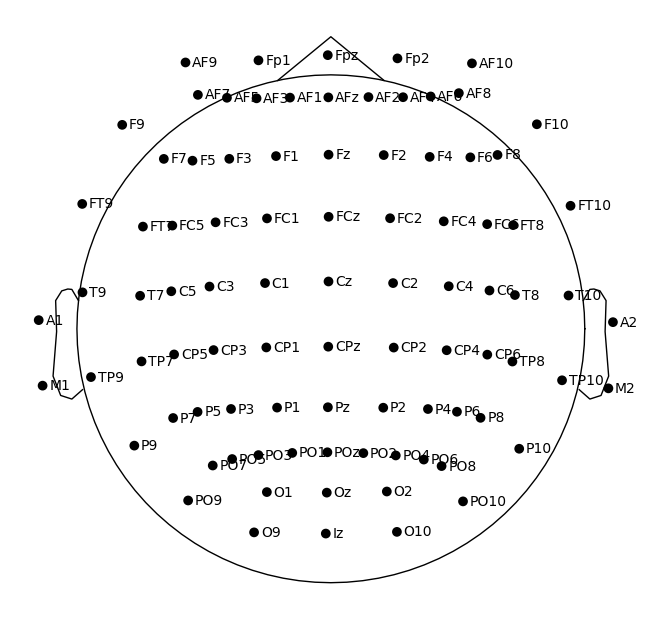

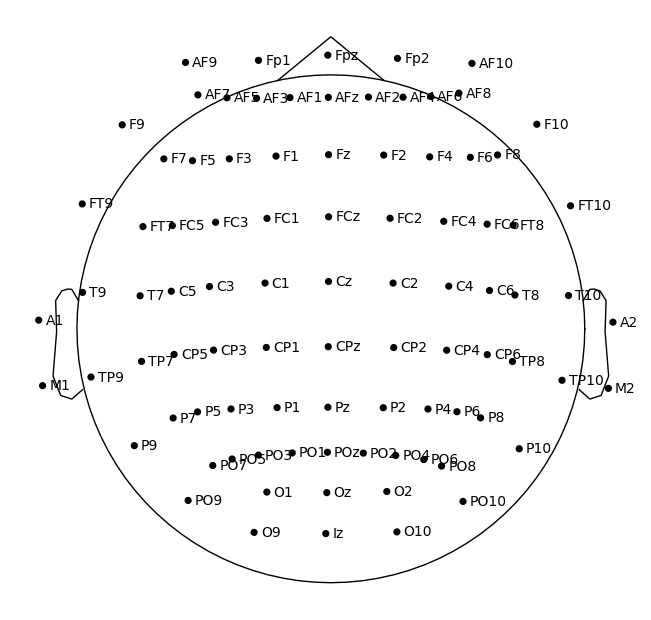

In [5]:
montage.plot(show_names=True)  # Plot the montage to visualize channel locations

### 2. Rereference

In [6]:
raw.set_eeg_reference('average', projection=True).apply_proj()

<RawBrainVision | sub-010003.eeg, 62 x 2519850 (1007.9 s), ~1.16 GiB, data loaded>

### 3. Divided into EO conditions and EC conditions

In [20]:
raw.plot(duration=10, scalings='auto', show=True, title='Raw EEG Data')

KeyboardInterrupt: 

In [21]:
# 1. Extract events and event_id dictionary from annotations in the raw data
events, event_id = mne.events_from_annotations(raw)
#print(event_id)

In [7]:
def divide_conditions_auto_margin(raw, min_block_sec=0.2):
    """    
    Divide EEG data into EO/EC blocks while automatically handling edges.
    
    Args:
        raw (mne.io.Raw): Loaded EEG data.
        min_block_sec (float): Minimum duration of a block to include (seconds).
        
    Returns:
        raw_eo, raw_ec (mne.io.Raw or None): Concatenated raw blocks per condition.
    """
    try:
        events, event_id = mne.events_from_annotations(raw)
    except Exception as e:
        print(f"Could not extract events: {e}")
        return None, None

    fs = raw.info['sfreq']
    data_end = raw.times[-1]

    eo_blocks, ec_blocks = [], []

    eo_code = event_id.get('Stimulus/S200', -1)
    ec_code = event_id.get('Stimulus/S210', -1)

    for i, event in enumerate(events[:-1]):
        t_start = event[0] / fs
        t_end = events[i + 1][0] / fs
        this_code = event[2]
        next_code = events[i + 1][2]

        # Automatically shrink margins if near edges
        t_start_safe = max(t_start, 0)
        t_end_safe = min(t_end, data_end)

        block_duration = t_end_safe - t_start_safe
        if block_duration < min_block_sec:
            continue  # Skip very short blocks

        if this_code == eo_code and next_code == eo_code:
            eo_blocks.append(raw.copy().crop(tmin=t_start_safe, tmax=t_end_safe, include_tmax=False))
        elif this_code == ec_code and next_code == ec_code:
            ec_blocks.append(raw.copy().crop(tmin=t_start_safe, tmax=t_end_safe, include_tmax=False))

    raw_eo = mne.concatenate_raws(eo_blocks) if eo_blocks else None
    raw_ec = mne.concatenate_raws(ec_blocks) if ec_blocks else None

    return raw_eo, raw_ec


In [8]:
raw_eo, raw_ec = divide_conditions_auto_margin(raw)

In [22]:
fs = int(raw.info['sfreq'])

eo_blocks = []
ec_blocks = []

# Get numeric event codes
eo_code = event_id.get('Stimulus/S200', -1)  # Eyes Open
ec_code = event_id.get('Stimulus/S210', -1)  # Eyes Closed

for i, event in enumerate(events[:-1]):  # skip last (no next)
    this_sample = event[0]
    this_code = event[2]
    
    next_sample = events[i + 1][0]
    next_code = events[i + 1][2]

    t_start = this_sample / fs
    t_end = next_sample / fs

    # Only include block if the same condition continues (no switch)
    if this_code == eo_code and next_code == eo_code:
        eo_blocks.append(raw.copy().crop(tmin=t_start, tmax=t_end, include_tmax=False))
    elif this_code == ec_code and next_code == ec_code:
        ec_blocks.append(raw.copy().crop(tmin=t_start, tmax=t_end, include_tmax=False))
    # Transitions (e.g., EO → EC or EC → EO) are skipped

# Concatenate all blocks
raw_eo = mne.concatenate_raws(eo_blocks) if eo_blocks else None
raw_ec = mne.concatenate_raws(ec_blocks) if ec_blocks else None

In [9]:
raw_eo.plot(duration=10, scalings='auto', show=True, title='Eyes Open')

### 4. Filtering the data

In [10]:
# Define IIR filter parameters: 8th-order Butterworth filter
iir_params = dict(order=8, ftype='butter')

# Apply a band-pass filter from 1 to 45 Hz using zero-phase filtering
raw_eo = raw_eo.copy().filter(
    l_freq=1.,              # Lower cutoff frequency (Hz)
    h_freq=45.,             # Upper cutoff frequency (Hz)
    method='iir',           # Use IIR filtering
    iir_params=iir_params,  # Specify filter order and type
    phase='zero',           # Apply zero-phase (forward-backward) filtering to avoid phase distortion
    verbose=True            # Print filtering information
)

raw_ec = raw_ec.copy().filter(
    l_freq=1.,              # Lower cutoff frequency (Hz)
    h_freq=45.,             # Upper cutoff frequency (Hz)
    method='iir',           # Use IIR filtering
    iir_params=iir_params,  # Specify filter order and type
    phase='zero',           # Apply zero-phase (forward-backward) filtering to avoid phase distortion
    verbose=True            # Print filtering information
)

Filtering raw data in 232 contiguous segments
Setting up band-pass filter from 1 - 45 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 32 (effective, after forward-backward)
- Cutoffs at 1.00, 45.00 Hz: -6.02, -6.02 dB

Filtering raw data in 232 contiguous segments
Setting up band-pass filter from 1 - 45 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 32 (effective, after forward-backward)
- Cutoffs at 1.00, 45.00 Hz: -6.02, -6.02 dB



In [18]:
# Show a short segment of the original raw EEG (before splitting)
raw.plot(title='Original raw EEG (before block splitting)', duration=20, start=0)

Using qt as 2D backend.


In [19]:
#eo_fname = 'D:\\FY2025\\Fukuyama\\work place\\original_preprocessed_data\\sub-010002\\sub-010002_EO.fif'
#ec_fname = 'D:\\FY2025\\Fukuyama\\work place\\original_preprocessed_data\\sub-010002\\sub-010002_EC.fif'

# Load raw data from FIF files
#raw_eo = mne.io.read_raw_fif(eo_fname, preload=True)
#raw_ec = mne.io.read_raw_fif(ec_fname, preload=True)

In [20]:
# Plot EC condition (eyes closed)
raw_ec.plot(title='Eyes Closed (EC)', duration=20, start=0)

In [11]:
events_ec, event_id_ec = mne.events_from_annotations(raw_ec)
print(events_ec)

[[  32622       0     210]
 [  37622       0     210]
 [  37622       0     210]
 ...
 [1187630       0     210]
 [1187630       0     210]
 [1192630       0     210]]


In [22]:
# Plot EO condition (eyes open)
raw_eo.plot(title='Eyes Open (EO)', duration=20, start=0)

In [23]:
events_eo, event_id_eo = mne.events_from_annotations(raw_eo)
print(events_eo)

Used Annotations descriptions: [np.str_('Stimulus/S200')]
[[ 171871       0     200]
 [ 176871       0     200]
 [ 176871       0     200]
 ...
 [1326888       0     200]
 [1326888       0     200]
 [1331888       0     200]]


In [12]:
duration_eo = raw_eo.times[-1]
duration_ec = raw_ec.times[-1]

print(f"Eyes Open (EO) duration: {duration_eo:.2f} sec")
print(f"Eyes Closed (EC) duration: {duration_ec:.2f} sec")

Eyes Open (EO) duration: 464.00 sec
Eyes Closed (EC) duration: 464.00 sec


### 5. Independent Component Analysis  (ICA)

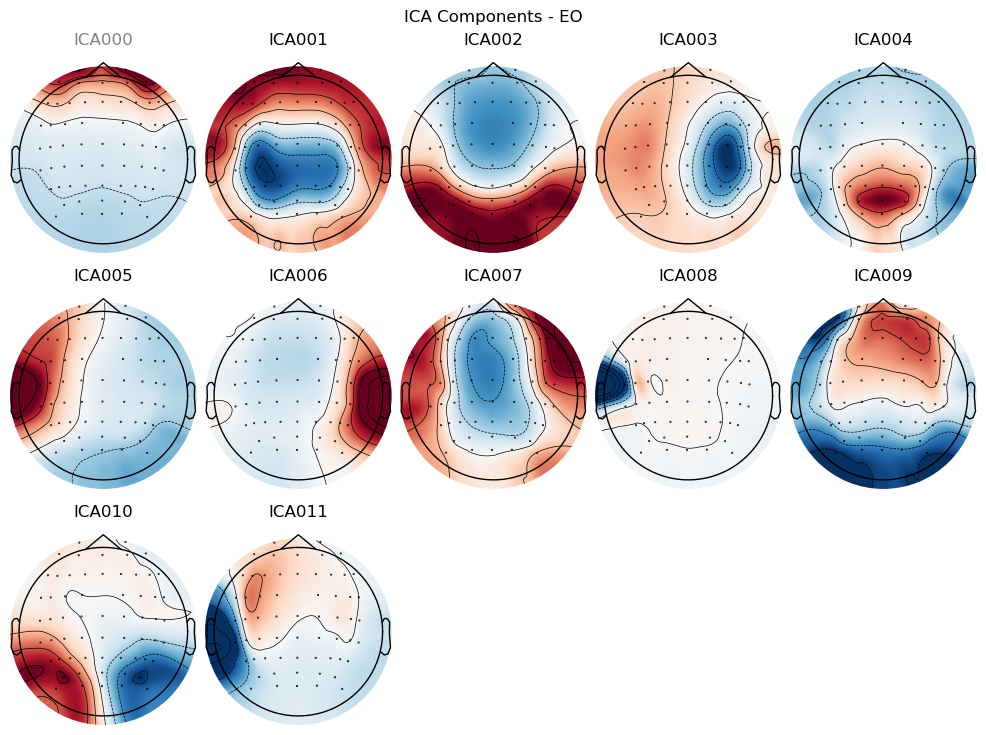

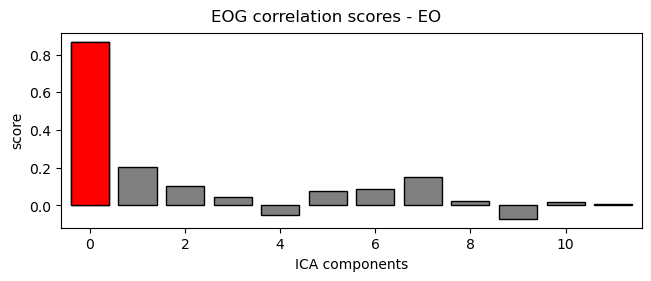

In [13]:
# Set parameters
n_components = 0.95  # retain 95% variance
method = 'infomax'   # ICA algorithm
random_state = 97    # for reproducibility

# ICA fitting for EO (Eyes Open) ###
ica_eo = mne.preprocessing.ICA(n_components=n_components, method=method, random_state=random_state)
ica_eo.fit(raw_eo)

# Detect and mark EOG artifacts (blink/movement)
eog_inds_eo, eog_scores_eo = ica_eo.find_bads_eog(raw_eo)
ica_eo.exclude = eog_inds_eo  # mark bad components

# Optional: Plot the components and scores for inspection
ica_eo.plot_components(title=f'ICA Components - EO')
ica_eo.plot_scores(eog_scores_eo, title=f'EOG correlation scores - EO')

# Apply ICA to remove marked components
raw_eo_clean = ica_eo.apply(raw_eo.copy())

    Applying projection operator with 1 vector (pre-whitener application)
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated


ValueError: `dataset` input should have multiple elements.

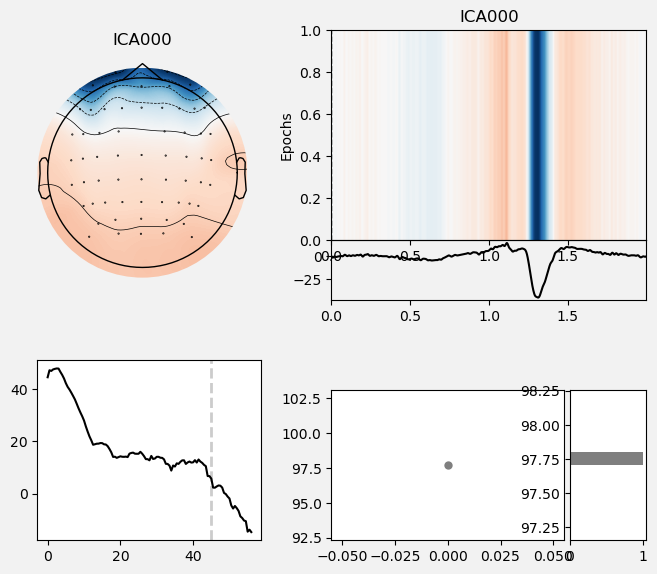

In [23]:
ica_eo.plot_properties(raw_eo, picks=[0])

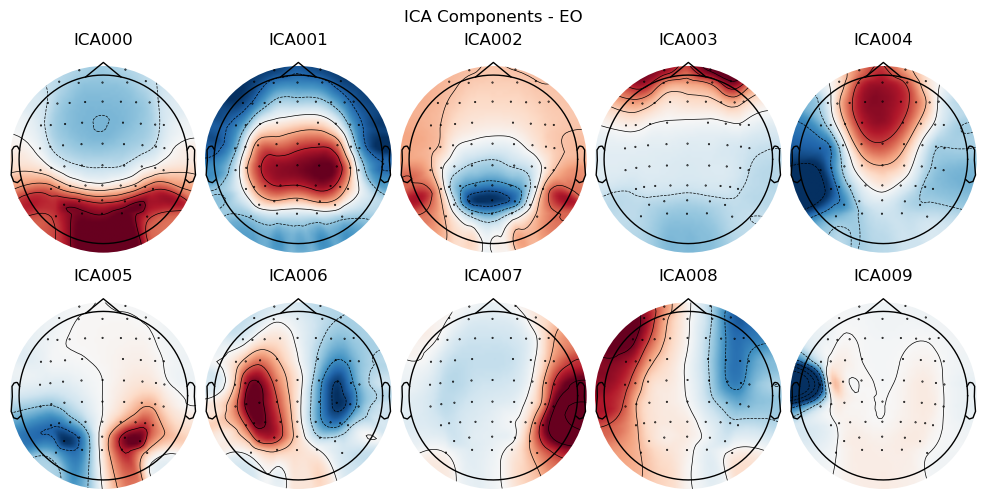

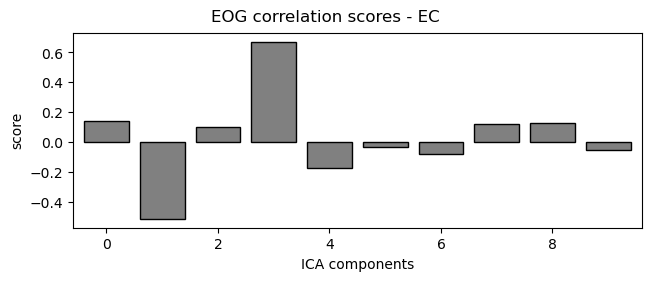

In [14]:
### Repeat for EC (Eyes Closed) ###
ica_ec = mne.preprocessing.ICA(n_components=n_components, method=method, random_state=random_state)
ica_ec.fit(raw_ec)

eog_inds_ec, eog_scores_ec = ica_ec.find_bads_eog(raw_ec)
ica_ec.exclude = eog_inds_ec

# Optional: Plot the components and scores for inspection
ica_ec.plot_components(title=f'ICA Components - EO')
ica_ec.plot_scores(eog_scores_ec, title=f'EOG correlation scores - EC')

raw_ec_clean = ica_ec.apply(raw_ec.copy())

In [13]:
print(raw_eo_clean)
print(raw_ec_clean)

<RawBrainVision | sub-010002.eeg, 62 x 1160017 (464.0 s), ~548.8 MiB, data loaded>
<RawBrainVision | sub-010002.eeg, 62 x 1160017 (464.0 s), ~548.8 MiB, data loaded>


In [27]:
explained_var_ratio = ica_eo.get_explained_variance_ratio(raw_eo_clean)
for channel_type, ratio in explained_var_ratio.items():
    print(f"Fraction of {channel_type} variance explained by all components: {ratio}")

Fraction of eeg variance explained by all components: 0.9339798309698916


In [28]:
explained_var_ratio = ica_ec.get_explained_variance_ratio(raw_ec_clean)
for channel_type, ratio in explained_var_ratio.items():
    print(f"Fraction of {channel_type} variance explained by all components: {ratio}")

NameError: name 'ica_ec' is not defined

    Applying projection operator with 1 vector (pre-whitener application)
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated


ValueError: `dataset` input should have multiple elements.

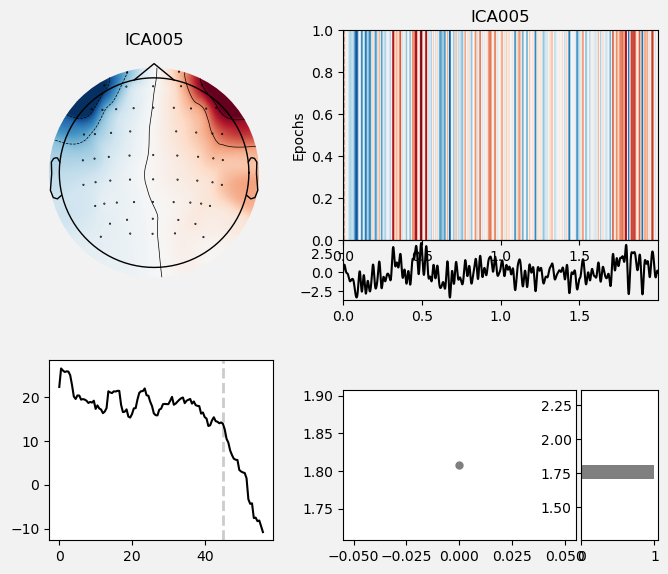

In [ ]:
ica_ec.plot_properties(raw_ec, picks=[5])
#ica_eo.plot_properties(inst=raw_eo_clean,picks=[0, 1],psd_args=dict(fmin=1., fmax=40.))

Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (17 components)
    Zeroing out 1 ICA component
    Projecting back using 61 PCA components


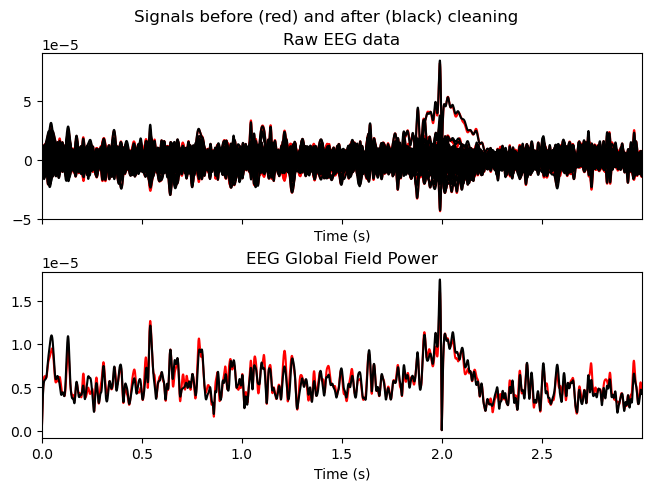

Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (17 components)
    Zeroing out 1 ICA component
    Projecting back using 61 PCA components


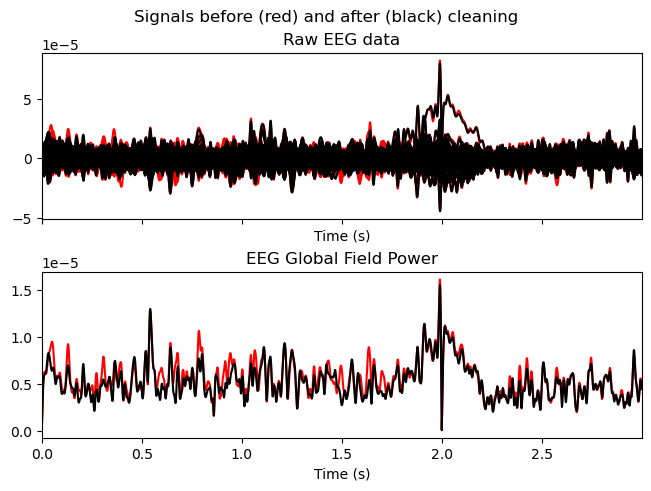

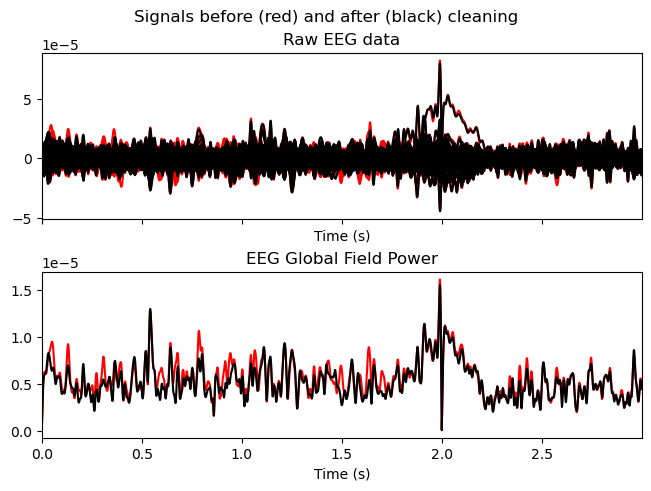

In [25]:
# blinks
ica_ec.plot_overlay(raw_ec, exclude=[0], picks="eeg")
# heartbeats
ica_ec.plot_overlay(raw_ec, exclude=[1], picks="eeg")

Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (14 components)
    Zeroing out 1 ICA component
    Projecting back using 61 PCA components


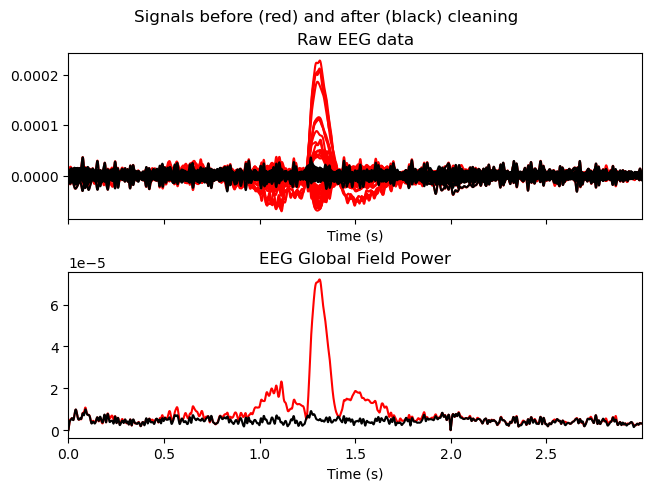

Applying ICA to Raw instance
    Applying projection operator with 1 vector (pre-whitener application)
    Transforming to ICA space (14 components)
    Zeroing out 2 ICA components
    Projecting back using 61 PCA components


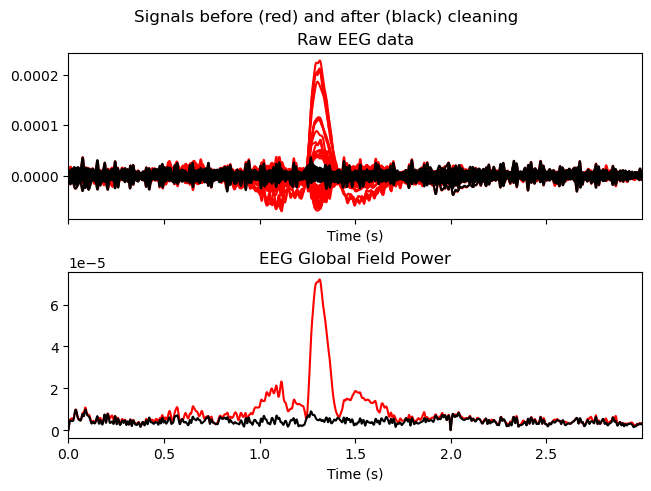

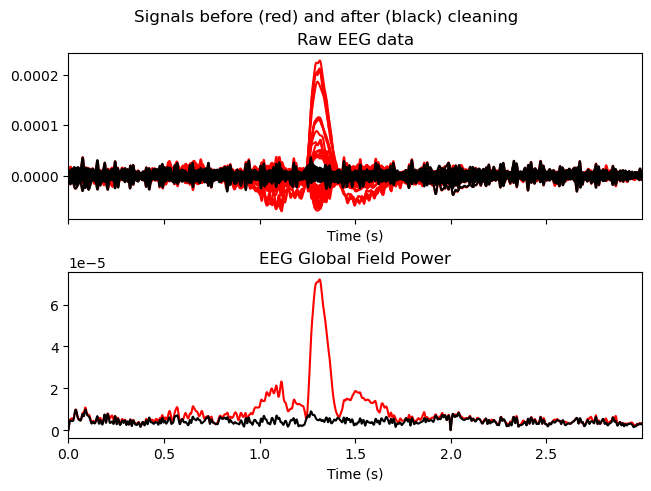

In [26]:
# blinks
ica_eo.plot_overlay(raw_eo, exclude=[0], picks="eeg")
# heartbeats
ica_eo.plot_overlay(raw_eo, exclude=[1], picks="eeg")

In [ ]:
# Specify file names for saving
eo_fname = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\original_preprocessed_data\\sub-010003\\sub-010002_EO.fif'
ec_fname = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\original_preprocessed_data\\sub-010003\\sub-010002_EC.fif'

# Save the segmented raw data to FIF files
# overwrite=True allows overwriting if files already exist
raw_eo_clean.save(eo_fname, overwrite=True)
raw_ec_clean.save(ec_fname, overwrite=True)

Overwriting existing file.
Writing D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EO.fif


C:\Users\sFukuyama\AppData\Local\Temp\3\ipykernel_34936\3755438090.py:7: RuntimeWarning: This filename (D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EO.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_eo_clean.save(eo_fname, overwrite=True)


Closing D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EO.fif
[done]
Overwriting existing file.
Writing D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EC.fif


C:\Users\sFukuyama\AppData\Local\Temp\3\ipykernel_34936\3755438090.py:8: RuntimeWarning: This filename (D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EC.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_ec_clean.save(ec_fname, overwrite=True)


Closing D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EC.fif
[done]


[WindowsPath('D:/FY2025/Fukuyama/work place/eeg-mri-aging-analysis/data/original_preprocessed_data/sub-010002/sub-010002_EC.fif')]

### 6. CSD

In [15]:
raw_ec_csd = mne.preprocessing.compute_current_source_density(raw_ec_clean)
raw_eo_csd = mne.preprocessing.compute_current_source_density(raw_eo_clean)

In [17]:
raw_ec_clean.plot()

In [18]:
raw_ec_csd.plot()

### 7. Save preprocessed EEG data  

In [19]:
# Specify file names for saving
eo_fname = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\original_preprocessed_data\\sub-010002\\sub-010002_EO.fif'
ec_fname = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\original_preprocessed_data\\sub-010002\\sub-010002_EC.fif'

# Save the segmented raw data to FIF files
# overwrite=True allows overwriting if files already exist
raw_eo_csd.save(eo_fname, overwrite=True)
raw_ec_csd.save(ec_fname, overwrite=True)

Overwriting existing file.
Writing D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EO.fif


C:\Users\sFukuyama\AppData\Local\Temp\3\ipykernel_34936\1734200077.py:7: RuntimeWarning: This filename (D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EO.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_eo_csd.save(eo_fname, overwrite=True)


Closing D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EO.fif
[done]
Overwriting existing file.
Writing D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EC.fif


C:\Users\sFukuyama\AppData\Local\Temp\3\ipykernel_34936\1734200077.py:8: RuntimeWarning: This filename (D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EC.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_ec_csd.save(ec_fname, overwrite=True)


Closing D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\original_preprocessed_data\sub-010002\sub-010002_EC.fif
[done]


[WindowsPath('D:/FY2025/Fukuyama/work place/eeg-mri-aging-analysis/data/original_preprocessed_data/sub-010002/sub-010002_EC.fif')]

In [42]:
epoch_duration = 2.0  # Duration of each epoch in seconds

events = mne.make_fixed_length_events(raw_eo_csd, id=1, duration=epoch_duration)
    
# Create epochs
epochs = mne.Epochs(raw_eo_csd, events, event_id=1, tmin=0, tmax=epoch_duration,
                    baseline=None, preload=True)

In [31]:
# Specify file names for saving
eo_fname = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\test\\sub-010003\\sub-010003_EO_eeg.fif'
ec_fname = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\test\\sub-010003\\sub-010003_EC_eeg.fif'

# Save the segmented raw data to FIF files
# overwrite=True allows overwriting if files already exist
raw_eo_clean.save(eo_fname, overwrite=True)
raw_ec_clean.save(ec_fname, overwrite=True)

[WindowsPath('D:/FY2025/Fukuyama/work place/eeg-mri-aging-analysis/data/test/sub-010003/sub-010003_EC_eeg.fif')]

In [37]:
id = 'sub-010003'
condition = 'EO' 

preprocess_path = 'D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\test'
path = os.path.join(preprocess_path, id, f"{id}_{condition}_eeg.fif")

raw = mne.io.read_raw_fif(path, preload=True)
raw.load_data()
#raw = raw.copy().pick("eeg")

<Raw | sub-010003_EO_eeg.fif, 62 x 1160009 (464.0 s), ~548.8 MiB, data loaded>

In [38]:
raw_csd = mne.preprocessing.compute_current_source_density(raw)

In [43]:
epoch_duration = 2.0  # Duration of each epoch in seconds

events = mne.make_fixed_length_events(raw_csd, id=1, duration=epoch_duration)
    
# Create epochs
epochs = mne.Epochs(raw_csd, events, event_id=1, tmin=0, tmax=epoch_duration,
                    baseline=None, preload=True)

C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_54308\2297094339.py:6: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(raw_csd, events, event_id=1, tmin=0, tmax=epoch_duration,


In [48]:
import mne

def safe_epoch_from_raw(raw, events, tmin=0.0, tmax=2.0, baseline=None, preload=True):
    """
    Save and epoch raw EEG data safely to avoid BAD boundary errors.

    Args:
        raw (mne.io.Raw): The raw EEG data.
        events (np.ndarray): Events array for epoching.
        tmin (float): Start time before event (s).
        tmax (float): End time after event (s).
        baseline (tuple or None): Baseline correction.
        preload (bool): Whether to preload epoched data.
    
    Returns:
        epochs (mne.Epochs): Epoched data without BAD boundary issues.
    """
    sfreq = raw.info['sfreq']
    
    # 安全に切り詰めて端の不完全エポックを避ける
    safe_tmax = raw.times[-1] - tmax
    if safe_tmax <= 0:
        raise ValueError("Raw data is too short for the requested tmax.")

    raw_cropped = raw.copy().crop(tmin=0, tmax=safe_tmax)

    # エポック化（BAD boundaryを無視して作成）
    epochs = mne.Epochs(
        raw_cropped, 
        events, 
        tmin=tmin, 
        tmax=tmax, 
        baseline=baseline, 
        preload=preload
        #reject_by_annotation=False
    )

    return epochs


In [49]:
events = mne.make_fixed_length_events(raw_csd, id=1, duration=epoch_duration)
    
# Create epochs
epochs = safe_epoch_from_raw(raw_csd, events, tmin=0, tmax=2.0)

C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_54308\1969320839.py:28: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


In [50]:
epochs.drop_log

((np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD boundary'),),
 (np.str_('BAD

In [26]:
epoch_duration = 2.0  # Duration of each epoch in seconds

events = mne.make_fixed_length_events(raw_eo_csd, id=1, duration=epoch_duration)
    
# Create epochs
epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=epoch_duration,
                    baseline=None, preload=True)

C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_54308\3894401298.py:6: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=epoch_duration,
